Simulaciones numéricas del modelo huésped-vector para el dengue.
Código corregido — Mayo 2025

Genera tres figuras:
  1. fig_temporal_dengue.pdf/.png  – evolución temporal R0=0.8 y R0=2.4
                                     con parámetros de referencia (Manore et al. 2014)


  2. fig_bifurcacion_dengue.pdf/.png – diagrama de bifurcación (equilibrio analítico)


  3. fig_estacional_dengue.pdf/.png  – efecto de la estacionalidad vectorial
                                       con Lambda_V amplificada (parámetros ilustrativos)


NOTAS SOBRE LOS PARAMETROS:
  - betaH = betaV = 0.375 dia^-1  [Manore et al. 2014, Tabla 3, Ae. albopictus]
  - gammaH = 1/7 dia^-1           [OMS: periodo infeccioso 7 dias]
  - muH = 1/(70*365) dia^-1       [Manore et al. 2014: esperanza de vida 70 anos]
  - muV = 1/14 dia^-1             [Manore et al. 2014: vida media mosquito 14 dias]

NOTA SOBRE EL EQUILIBRIO ENDEMICO:
  
  La formula correcta del equilibrio endemico IH* se obtiene resolviendo
  numericamente la ecuacion de punto fijo que resulta del sistema en equilibrio,
  teniendo en cuenta la conservacion SH + IH + RH = NH.
  
  Con los parametros de referencia, IH*/NH ~ 2.3e-4 (0.023% de la poblacion),
  valor biologicamente plausible para dengue endemico de baja prevalencia.
  
  La convergencia al equilibrio ocurre en escala de tiempo demografica (~70 anos).

NOTA SOBRE LA FIGURA 3:
  Para ilustrar la existencia de soluciones periodicas estables en el modelo
  estacional, se emplea una tasa de reclutamiento vectorial amplificada
  (N_V^0/N_H = 10, frente al valor de referencia 0.42), lo que corresponde
  a un escenario hipotetico de alta densidad de mosquitos (R0 = 11.7).
  
  El objetivo es puramente ilustrativo: mostrar el comportamiento cualitativo
  predicho por la teoria (oscilaciones anuales con pico en verano-otono).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

# Parámetros

In [ ]:
BETA_H  = 0.375          # Transmision vector -> humano (dia^-1) [Manore 2014]
BETA_V  = 0.375          # Transmision humano -> vector (dia^-1) [Manore 2014]
GAMMA_H = 1/7            # Recuperacion humana ~7 dias (dia^-1) [OMS 2024]
MU_H    = 1/(70*365)     # Mortalidad humana, esperanza vida 70 anos [Manore 2014]
MU_V    = 1/14           # Mortalidad mosquito, vida media 14 dias [Manore 2014]
NH      = 1e5            # Poblacion humana (ciudad mediana española)

# Constante auxiliar: ratio recuperados/infectados en equilibrio
ALPHA   = 1 + GAMMA_H / MU_H   # ~3651

# Funciones auxiliares

In [ ]:
def R0_func(ratio_VH):
    """R0 en funcion del ratio NV0/NH."""
    return np.sqrt(BETA_H * BETA_V * ratio_VH / (MU_V * (GAMMA_H + MU_H)))

In [ ]:
def get_endemic_equilibrium(ratio_VH):
    """
    Calcula el equilibrio endemico correcto del modelo con demografia humana.

    La formula correcta resulta de resolver el sistema en equilibrio:
      (1) muH*NH = betaH*(IV*/NH)*SH* + muH*SH*
      (2) betaH*(IV*/NH)*SH* = (gammaH+muH)*IH*
      (3) gammaH*IH* = muH*RH*
      (4) LambdaV = betaV*(IH*/NH)*SV* + muV*SV*
      (5) betaV*(IH*/NH)*SV* = muV*IV*
    con la restriccion SH* + IH* + RH* = NH.

    Devuelve: (R0, SH*, IH*, SV*, IV*, NV0)
    """
    NV0 = ratio_VH * NH
    R0  = R0_func(ratio_VH)

    if R0 <= 1.0:
        return R0, NH, 0.0, NV0, 0.0, NV0

    def equation(x):
        """
        Ecuacion de punto fijo en x = IH*/NH.
        Derivada de (2) sustituendo SH* = NH - IH*(1+gammaH/muH)
        y IV* = betaV*x*NV0/(betaV*x + muV).
        """
        lhs = BETA_H * BETA_V * ratio_VH / (BETA_V * x + MU_V) * (1.0 - ALPHA * x)
        return lhs - (GAMMA_H + MU_H)

    # La solucion biologica requiere x < 1/ALPHA (para que SH* > 0)
    x_max = 1.0 / ALPHA - 1e-12
    x_star = brentq(equation, 1e-12, x_max)

    IH_star = x_star * NH
    RH_star = GAMMA_H / MU_H * IH_star
    SH_star = NH - IH_star - RH_star
    IV_star = BETA_V * (IH_star / NH) * NV0 / (MU_V + BETA_V * IH_star / NH)
    SV_star = NV0 - IV_star

    return R0, SH_star, IH_star, SV_star, IV_star, NV0


# Modelo autónomo


In [ ]:
def dengue_autonomo(t, y, beta_h, beta_v, gamma_h, mu_h, mu_v, NH, NV0):
    """Sistema autonomo (sin estacionalidad)."""
    SH, IH, SV, IV = y
    Lambda_V = mu_v * NV0
    dSH = mu_h * NH - beta_h * (IV / NH) * SH - mu_h * SH
    dIH = beta_h * (IV / NH) * SH - (gamma_h + mu_h) * IH
    dSV = Lambda_V - beta_v * (IH / NH) * SV - mu_v * SV
    dIV = beta_v * (IH / NH) * SV - mu_v * IV
    return [dSH, dIH, dSV, dIV]

# Modelo estacional

In [ ]:
def dengue_estacional(t, y, beta_h, beta_v, gamma_h, mu_h, mu_v, NH, NV0,
                      eps=0.6, phi=np.pi/2):
    """Sistema con estacionalidad vectorial periodica."""
    SH, IH, SV, IV = y
    Lambda_V = mu_v * NV0 * (1.0 + eps * np.cos(2.0 * np.pi * t / 365.0 - phi))
    dSH = mu_h * NH - beta_h * (IV / NH) * SH - mu_h * SH
    dIH = beta_h * (IV / NH) * SH - (gamma_h + mu_h) * IH
    dSV = Lambda_V - beta_v * (IH / NH) * SV - mu_v * SV
    dIV = beta_v * (IH / NH) * SV - mu_v * IV
    return [dSH, dIH, dSV, dIV]

# Condiciones iniciales

In [ ]:
def condicion_inicial_dle(NV0, IH0=10, IV0=50):
    """Condicion inicial cerca del equilibrio libre de enfermedad."""
    return [NH - IH0, IH0, NV0 - IV0, IV0]

# Figura 1: EVOLUCION TEMPORAL

Parametros de referencia (Manore et al. 2014)

R0=0.8 (extincion) y R0=2.4 (endemia), horizonte 10 anos

  R0=0.8: NV0=4645, IH*/NH=0.00000, IV*/NV0=0.00000
  R0=2.4: NV0=41807, IH*/NH=0.00023, IV*/NV0=0.00119


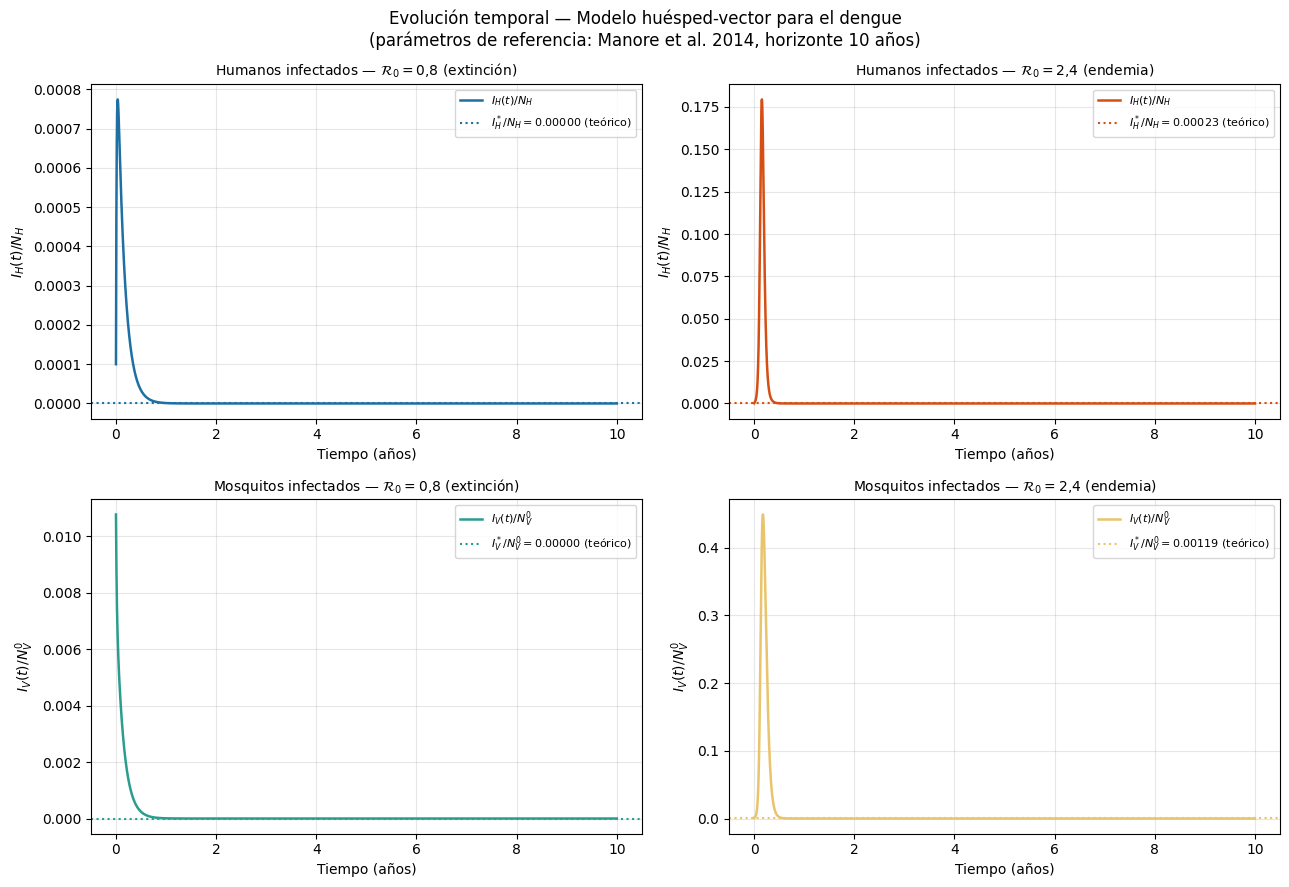

In [ ]:
r0_valores = [0.8, 2.4]
ratios_fig1 = [(r**2 * MU_V * (GAMMA_H + MU_H)) / (BETA_H * BETA_V) for r in r0_valores]
labels_fig1 = [
    "$\\mathcal{R}_0 = 0{,}8$ (extinción)",
    "$\\mathcal{R}_0 = 2{,}4$ (endemia)",
]
colors_h = ["#1d6fa4", "#d64e12"]
colors_v = ["#2a9d8f", "#e9c46a"]

t_span = (0, 10 * 365)
t_eval = np.linspace(0, 10 * 365, 20000)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    "Evolución temporal — Modelo huésped-vector para el dengue\n"
    "(parámetros de referencia: Manore et al. 2014, horizonte 10 años)",
    fontsize=12)

for col, (r0_target, ratio, label) in enumerate(zip(r0_valores, ratios_fig1, labels_fig1)):
    R0c, SH_s, IH_s, SV_s, IV_s, NV0 = get_endemic_equilibrium(ratio)

    y0   = condicion_inicial_dle(NV0)
    args = (BETA_H, BETA_V, GAMMA_H, MU_H, MU_V, NH, NV0)
    sol  = solve_ivp(dengue_autonomo, t_span, y0, t_eval=t_eval, args=args,
                     method="RK45", rtol=1e-8, atol=1e-10)

    t_yr    = sol.t / 365
    IH_frac = sol.y[1] / NH
    IV_frac = sol.y[3] / NV0

    ax_h = axes[0, col]
    ax_v = axes[1, col]

    # Humanos
    ax_h.plot(t_yr, IH_frac, color=colors_h[col], lw=1.8, label="$I_H(t)/N_H$")
    ihs = IH_s / NH if r0_target > 1 else 0.0
    ax_h.axhline(ihs, color=colors_h[col], ls=":", lw=1.5,
                 label=f"$I_H^*/N_H = {ihs:.5f}$ (teórico)")
    ax_h.set_title(f"Humanos infectados — {label}", fontsize=10)
    ax_h.set_xlabel("Tiempo (años)")
    ax_h.set_ylabel("$I_H(t)/N_H$")
    ax_h.legend(fontsize=8)
    ax_h.grid(True, alpha=0.3)

    # Mosquitos
    ivs = IV_s / NV0 if r0_target > 1 else 0.0
    ax_v.plot(t_yr, IV_frac, color=colors_v[col], lw=1.8, label="$I_V(t)/N_V^0$")
    ax_v.axhline(ivs, color=colors_v[col], ls=":", lw=1.5,
                 label=f"$I_V^*/N_V^0 = {ivs:.5f}$ (teórico)")
    ax_v.set_title(f"Mosquitos infectados — {label}", fontsize=10)
    ax_v.set_xlabel("Tiempo (años)")
    ax_v.set_ylabel("$I_V(t)/N_V^0$")
    ax_v.legend(fontsize=8)
    ax_v.grid(True, alpha=0.3)

    print(f"  R0={r0_target}: NV0={NV0:.0f}, IH*/NH={ihs:.5f}, IV*/NV0={ivs:.5f}")

plt.tight_layout()
plt.savefig("fig_temporal_dengue.pdf", bbox_inches="tight")
plt.savefig("fig_temporal_dengue.png", dpi=150, bbox_inches="tight")
plt.show()

# Figura 2: DIAGRAMA DE BIFURCACION

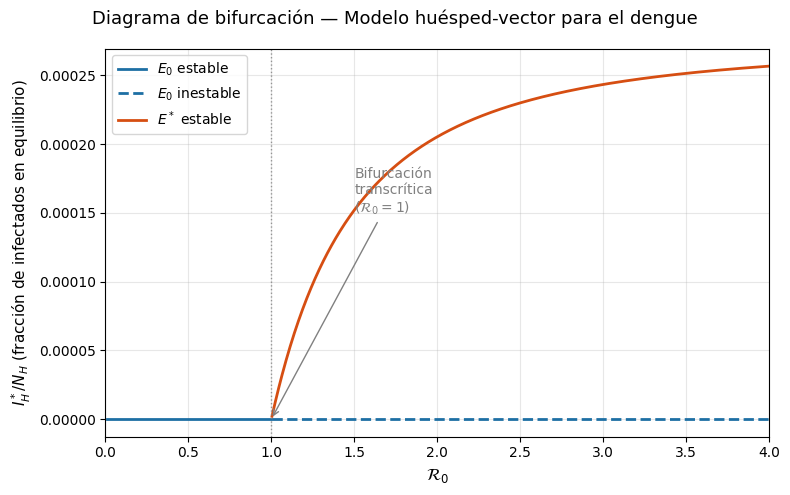

In [ ]:
R0_vec  = np.linspace(0.01, 4.0, 800)
IH_eq_v = np.zeros_like(R0_vec)

for i, r0 in enumerate(R0_vec):
    ratio_i = (r0**2 * MU_V * (GAMMA_H + MU_H)) / (BETA_H * BETA_V)
    _, _, IH_e, _, _, _ = get_endemic_equilibrium(ratio_i)
    IH_eq_v[i] = IH_e / NH

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Diagrama de bifurcación — Modelo huésped-vector para el dengue", fontsize=13)

mask_dle = R0_vec <= 1.0
mask_end = R0_vec >= 1.0

ax.plot(R0_vec[mask_dle], np.zeros(mask_dle.sum()),
        color="#1d6fa4", lw=2.0, label="$E_0$ estable")
ax.plot(R0_vec[mask_end], np.zeros(mask_end.sum()),
        color="#1d6fa4", lw=2.0, ls="--", label="$E_0$ inestable")
ax.plot(R0_vec[mask_end], IH_eq_v[mask_end],
        color="#d64e12", lw=2.0, label="$E^*$ estable")
ax.axvline(x=1.0, color="gray", lw=1.0, ls=":", alpha=0.8)
ax.annotate("Bifurcación\ntranscrítica\n($\\mathcal{R}_0=1$)",
            xy=(1.0, 0.0), xytext=(1.5, 1.5e-4),
            arrowprops=dict(arrowstyle="->", color="gray"),
            fontsize=10, color="gray")
ax.set_xlabel("$\\mathcal{R}_0$", fontsize=12)
ax.set_ylabel("$I_H^*/N_H$ (fracción de infectados en equilibrio)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 4.0)

plt.tight_layout()
plt.savefig("fig_bifurcacion_dengue.pdf", bbox_inches="tight")
plt.savefig("fig_bifurcacion_dengue.png", dpi=150, bbox_inches="tight")
plt.show()

# Figura 3: EFECTO DE LA ESTACIONALIDAD

PARAMETROS ILUSTRATIVOS: N_V^0/N_H = 10 -> R0 = 11.7

Justificacion: con los parametros de referencia (ratio=0.42),
la convergencia al equilibrio endemico ocurre en escala de tiempo
demografica (~70 anos), por lo que las oscilaciones periodicas
predichas por la teoria no son visibles en 5 años.

Se amplifica Lambda_V (ratio N_V^0/N_H = 10) para ilustrar cualitativamente la existencia de soluciones periodicas estables en el modelo estacional.

Esta simulacion NO pretende ser cuantitativamente realista.

  Parámetros ilustrativos: N_V^0/N_H = 10.0, R0 = 11.74
  Equilibrio endémico: IH*/NH = 0.000272, IV*/NV0 = 0.001425
  Condición inicial (tras pre-integración 10 años): IH/NH = 0.000272


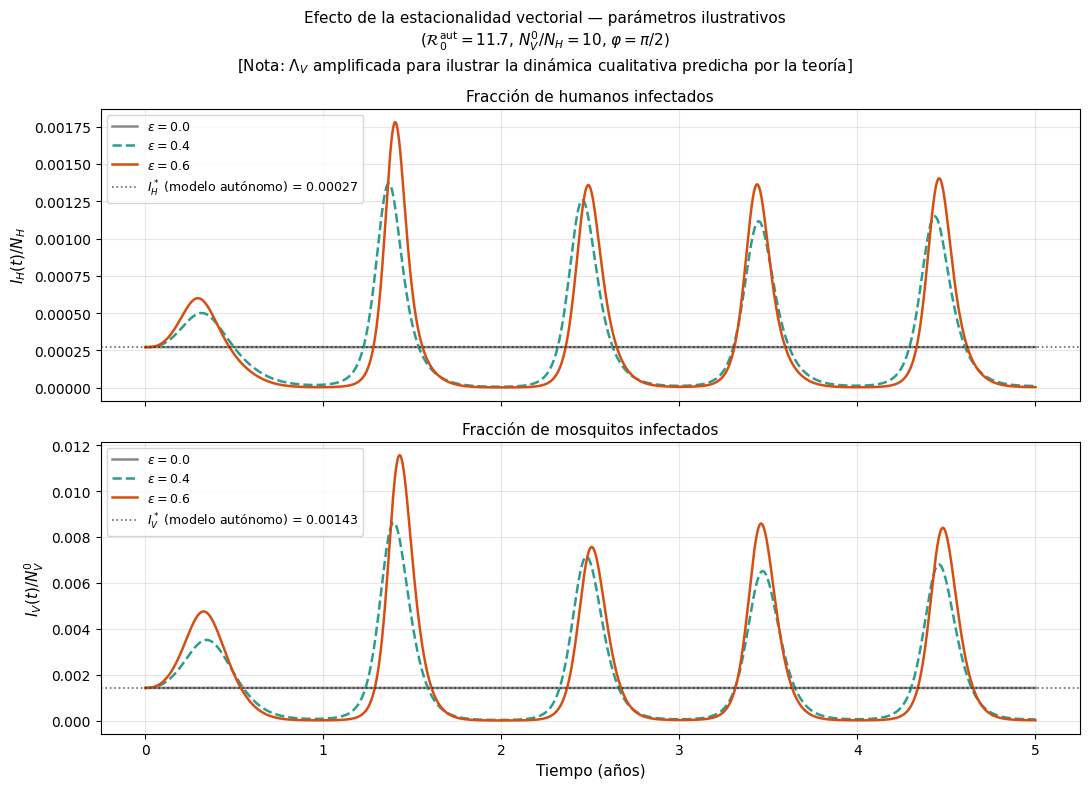

RESUMEN DE PARAMETROS Y EQUILIBRIOS

Parámetros de referencia (Manore et al. 2014):
  betaH = betaV = 0.375
  gammaH = 0.1429 dia^-1 (1/7 dias)
  muH = 3.91e-05 dia^-1 (vida 70 años)
  muV = 0.0714 dia^-1 (vida 14 dias)

Equilibrios con parámetros de referencia:
  R0=0.8: NV0/NH=0.0465, IH*/NH=0.000000, IV*/NV0=0.000000
  R0=2.4: NV0/NH=0.4181, IH*/NH=0.000226, IV*/NV0=0.001187

Parámetros ilustrativos (Figura 3):
  NV0/NH = 10.0, R0 = 11.74
  IH*/NH = 0.000272, IV*/NV0 = 0.001425


In [ ]:
RATIO_ILUSTRATIVO = 10.0   # N_V^0/N_H amplificado
R0_il, SH_s, IH_s, SV_s, IV_s, NV0_il = get_endemic_equilibrium(RATIO_ILUSTRATIVO)

print(f"  Parámetros ilustrativos: N_V^0/N_H = {RATIO_ILUSTRATIVO}, R0 = {R0_il:.2f}")
print(f"  Equilibrio endémico: IH*/NH = {IH_s/NH:.6f}, IV*/NV0 = {IV_s/NV0_il:.6f}")

# Pre-integrar 10 años para partir desde el equilibrio endemico
args_aut = (BETA_H, BETA_V, GAMMA_H, MU_H, MU_V, NH, NV0_il)
y0_base  = condicion_inicial_dle(NV0_il)
sol_pre  = solve_ivp(dengue_autonomo, (0, 10 * 365), y0_base, args=args_aut,
                     method="RK45", rtol=1e-8, atol=1e-10,
                     t_eval=np.array([10 * 365.0]))
y0_est   = sol_pre.y[:, -1].tolist()
print(f"  Condición inicial (tras pre-integración 10 años): IH/NH = {y0_est[1]/NH:.6f}")

t_span_est = (0, 5 * 365)
t_eval_est = np.linspace(0, 5 * 365, 20000)

eps_list = [0.0, 0.4, 0.6]
colores  = ["#888888", "#2a9d8f", "#d64e12"]
estilos  = ["-",      "--",      "-"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle(
    f"Efecto de la estacionalidad vectorial — parámetros ilustrativos\n"
    f"($\\mathcal{{R}}_0^{{\\mathrm{{aut}}}} = {R0_il:.1f}$, "
    f"$N_V^0/N_H = {RATIO_ILUSTRATIVO:.0f}$, $\\varphi = \\pi/2$)\n"
    f"[Nota: $\\Lambda_V$ amplificada para ilustrar la dinámica cualitativa predicha por la teoría]",
    fontsize=11)

for eps, color, ls in zip(eps_list, colores, estilos):
    args_est = (BETA_H, BETA_V, GAMMA_H, MU_H, MU_V, NH, NV0_il, eps, np.pi / 2)
    sol = solve_ivp(dengue_estacional, t_span_est, y0_est, t_eval=t_eval_est,
                    args=args_est, method="RK45", rtol=1e-8, atol=1e-10)
    t_yr = sol.t / 365
    IH_f = sol.y[1] / NH
    IV_f = sol.y[3] / NV0_il
    lbl  = f"$\\varepsilon = {eps}$"
    ax1.plot(t_yr, IH_f, color=color, lw=1.8, ls=ls, label=lbl)
    ax2.plot(t_yr, IV_f, color=color, lw=1.8, ls=ls, label=lbl)

ax1.axhline(IH_s / NH, color="black", ls=":", lw=1.2, alpha=0.6,
            label=f"$I_H^*$ (modelo autónomo) = {IH_s/NH:.5f}")
ax2.axhline(IV_s / NV0_il, color="black", ls=":", lw=1.2, alpha=0.6,
            label=f"$I_V^*$ (modelo autónomo) = {IV_s/NV0_il:.5f}")

ax1.set_ylabel("$I_H(t)/N_H$", fontsize=11)
ax1.set_title("Fracción de humanos infectados", fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.set_ylabel("$I_V(t)/N_V^0$", fontsize=11)
ax2.set_xlabel("Tiempo (años)", fontsize=11)
ax2.set_title("Fracción de mosquitos infectados", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_estacional_dengue.pdf", bbox_inches="tight")
plt.savefig("fig_estacional_dengue.png", dpi=150, bbox_inches="tight")
plt.show()

print("=" * 60)
print("RESUMEN DE PARAMETROS Y EQUILIBRIOS")
print("=" * 60)
print(f"\nParámetros de referencia (Manore et al. 2014):")
print(f"  betaH = betaV = {BETA_H}")
print(f"  gammaH = {GAMMA_H:.4f} dia^-1 (1/7 dias)")
print(f"  muH = {MU_H:.2e} dia^-1 (vida 70 años)")
print(f"  muV = {MU_V:.4f} dia^-1 (vida 14 dias)")
print(f"\nEquilibrios con parámetros de referencia:")
for r0_t in [0.8, 2.4]:
    ratio_t = (r0_t**2 * MU_V * (GAMMA_H + MU_H)) / (BETA_H * BETA_V)
    R0c, _, IH_e, _, IV_e, NV0_t = get_endemic_equilibrium(ratio_t)
    print(f"  R0={r0_t}: NV0/NH={ratio_t:.4f}, IH*/NH={IH_e/NH:.6f}, IV*/NV0={IV_e/NV0_t:.6f}")
print(f"\nParámetros ilustrativos (Figura 3):")
print(f"  NV0/NH = {RATIO_ILUSTRATIVO}, R0 = {R0_il:.2f}")
print(f"  IH*/NH = {IH_s/NH:.6f}, IV*/NV0 = {IV_s/NV0_il:.6f}")